# Setup & Settings

In [42]:
import os
import sys
import json
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as sps
import matplotlib.pyplot as plt

s_base_path = '/discover/nobackup/cmalings/output/ASIA-AQ/deepsensor_working_data'

def F_load_results(s_model):
    l_folders = [s_folder for s_folder in os.listdir(s_base_path) if s_model in s_folder]
    l_errors = []
    for s_folder in l_folders:
        f_errors_temp = pd.read_csv(os.path.join(s_base_path,s_folder,'evaluation_errors.csv'))
        f_errors_temp['time'] = pd.to_datetime(f_errors_temp['time'])
        l_errors += [f_errors_temp]
    f_errors = pd.concat(l_errors)
    f_errors = f_errors.set_index(['time','lat','lon'])
    return f_errors

def F_evaluate_metrics(f_errors_in,l_to_evaluate = ['Model','Baseline_GEOSCF','Baseline_Nearest'],v_special_times_to_evaluate=None):
    if v_special_times_to_evaluate is not None:
        l_desired_times = [str(desired_time)[0:19].replace('T',' ') for desired_time in v_special_times_to_evaluate]
        f_errors = f_errors_in.loc[l_desired_times]
    else:
        f_errors = f_errors_in
    
    bias = f_errors[l_to_evaluate].mean()
    mae = abs(f_errors[l_to_evaluate]).mean()
    ms_res = ((f_errors[l_to_evaluate])**2).mean()
    rmse = ms_res**0.5
    ms_tot = ((f_errors['Truth'] - f_errors['Truth'].mean())**2).mean()
    r2_all = 1-(ms_res/ms_tot)
    # !!! There is some issue with the correlation calculation, observed when running on GPU !!!
    try:
        r_all = np.corrcoef(np.concatenate([np.array([f_errors['Truth']]).transpose(),
                                            np.repeat(np.array([f_errors['Truth']]), len(l_to_evaluate), axis=0).transpose() + np.array(f_errors[l_to_evaluate])
                                           ],axis=1).transpose())[0,1:len(l_to_evaluate)+1]
    except:
        r_all = []
        for s_col in l_to_evaluate:
            v_y = f_errors['Truth'] - f_errors['Truth'].mean()
            v_x = (f_errors[s_col] + f_errors['Truth']) - (f_errors[s_col] + f_errors['Truth']).mean()
            n_r = ((v_x * v_y).sum())/((((v_x**2).sum())**0.5)*(((v_y**2).sum())**0.5))
            r_all += [n_r]
        
    ms_res_time = ((f_errors[l_to_evaluate])**2).groupby(['lat','lon']).mean()
    ms_tot_time = ((f_errors['Truth'] - f_errors['Truth'].mean())**2).groupby(['lat','lon']).mean()
    r2_all_time = ms_res_time.join(ms_tot_time)
    for s_to_evalaute in l_to_evaluate:
        r2_all_time[s_to_evalaute] = 1-(r2_all_time[s_to_evalaute]/r2_all_time['Truth'])
    r2_med_time = r2_all_time[l_to_evaluate].median()
    r2_avg_time = r2_all_time[l_to_evaluate].mean()
    
    ms_res_space = ((f_errors[l_to_evaluate])**2).groupby(['time']).mean()
    ms_tot_space = ((f_errors['Truth'] - f_errors['Truth'].mean())**2).groupby(['time']).mean()
    r2_all_space = ms_res_space.join(ms_tot_space)
    for s_to_evalaute in l_to_evaluate:
        r2_all_space[s_to_evalaute] = 1-(r2_all_space[s_to_evalaute]/r2_all_space['Truth'])
    r2_med_space = r2_all_space[l_to_evaluate].median()
    r2_avg_space = r2_all_space[l_to_evaluate].mean()

    f_metrics = pd.DataFrame({'Bias':bias,
                              'MAE':mae,
                              'RMSE':rmse,
                              'r (all)':r_all,
                              'R^2 (all)':r2_all,
                              'R^2 (space, median)':r2_med_space,
                              'R^2 (time, median)':r2_med_time,
                             })
    
    return f_metrics

# Load Results

In [44]:
l_models_to_load = ['Baseline_GEOSCF',
                    'Baseline_AirKorea',
                   ]
d_errors = {}
d_metrics = {}
d_model_rename = {'Baseline_GEOSCF':'CNP_GEOSCF',
                  'Baseline_AirKorea':'CNP_AirKorea',
                  'FullModel_wo_AK':'CNP_Full_noAK',
                  'FullModel_wi_AK':'CNP_Full_AK',
                 }

for s_model in l_models_to_load:
    d_errors[s_model] = F_load_results(s_model)
    try:
        d_metrics[s_model] = F_evaluate_metrics(d_errors[s_model])
    except:
        d_metrics[s_model] = F_evaluate_metrics(d_errors[s_model],l_to_evaluate = ['Model','Baseline_Nearest'])
        
    d_metrics[s_model].rename(index={'Model':d_model_rename[s_model]},inplace=True)
    print(f'Loaded Results for {s_model}')

Loaded Results for Baseline_GEOSCF
Loaded Results for Baseline_AirKorea


# Check Results for Individual Model

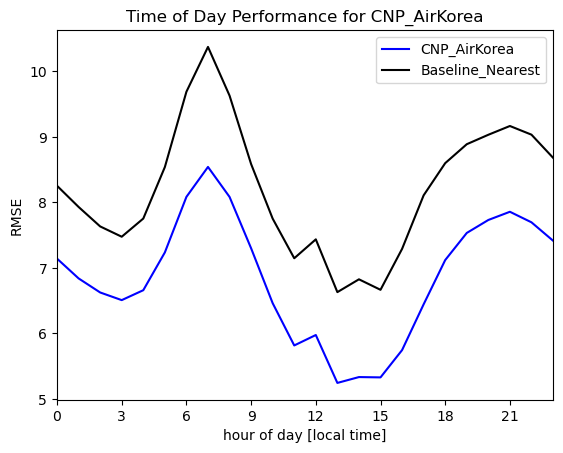

Representation of Uncertainty for CNP_AirKorea
Mean: 0.0878599402178908 [Ideal: 0]
Standard Deviation: 1.1887912540565184 [Ideal: 1]
Skewness: -1.6886048316955566 [Ideal: 0]
Kurtosis: 13.465652465820312 [Ideal: 0]


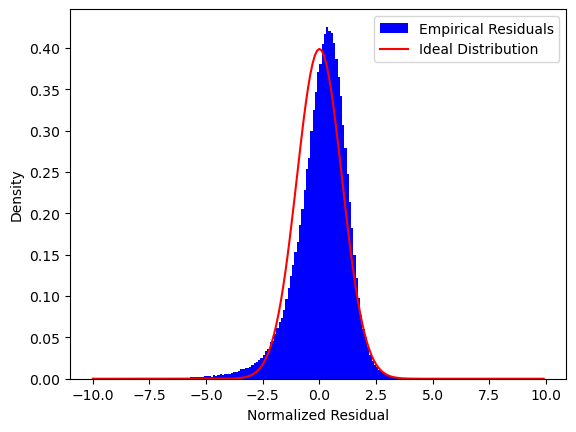

,Bias,MAE,RMSE,r (all),R^2 (all),"R^2 (space, median)","R^2 (time, median)",Baseline_GEOSCF
CNP_AirKorea,0.818692,4.920271,6.934842,0.838075,0.690478,0.664043,0.747010,NaN
Baseline_Nearest,0.363077,5.700180,8.280705,0.782410,0.558681,0.521245,0.635212,NaN


In [47]:
s_model = 'Baseline_AirKorea'

# Evaluate time-of-day performance
v_hour = pd.to_datetime(d_errors[s_model].reset_index()['time']).dt.hour
v_hour.index = d_errors[s_model].index

n_UTC_offset = 9

d_hourly_metrics = {}
for i_hour in range(0,24):
    i_hour_utc = (i_hour - n_UTC_offset) % 24
    try:
        d_hourly_metrics[i_hour] = F_evaluate_metrics(d_errors[s_model][v_hour == i_hour_utc])
    except:
        d_hourly_metrics[i_hour] = F_evaluate_metrics(d_errors[s_model][v_hour == i_hour_utc],l_to_evaluate = ['Model','Baseline_Nearest'])

s_metric_to_plot = 'RMSE'

plt.plot(range(0,24),[d_hourly_metrics[i_hour][s_metric_to_plot]['Model'] for i_hour in range(0,24)],label=d_model_rename[s_model],color='blue')
try:
    plt.plot(range(0,24),[d_hourly_metrics[i_hour][s_metric_to_plot]['Baseline_GEOSCF'] for i_hour in range(0,24)],label='Baseline_GEOSCF',color='red')
except:
    pass
plt.plot(range(0,24),[d_hourly_metrics[i_hour][s_metric_to_plot]['Baseline_Nearest'] for i_hour in range(0,24)],label='Baseline_Nearest',color='black')
plt.xlabel('hour of day [local time]')
plt.xlim([0,23])
plt.xticks(np.arange(0,24,3))
plt.ylabel(s_metric_to_plot)
plt.title(f'Time of Day Performance for {d_model_rename[s_model]}')
plt.legend()
plt.show()

# Evaluate Uncertainty Representation
v_bins = np.arange(-10,10,0.1)
v_residuals = d_errors[s_model]['Model_Normalized'].values

# Compute Mean, SD, Skewness, Kurtosis
print(f'Representation of Uncertainty for {d_model_rename[s_model]}')
print(f'Mean: {v_residuals.mean()} [Ideal: 0]')
print(f'Standard Deviation: {v_residuals.std()} [Ideal: 1]')
print(f'Skewness: {sps.skew(v_residuals.astype('f'))} [Ideal: 0]')
print(f'Kurtosis: {sps.kurtosis(v_residuals.astype('f'))} [Ideal: 0]')

# plot histogram of residuals
plt.hist(v_residuals,bins=v_bins,color='blue',label='Empirical Residuals',density=True)
# plot normal distrubution
plt.plot(v_bins,sps.norm.pdf(v_bins),color='red',label='Ideal Distribution')

plt.xlabel('Normalized Residual')
plt.ylabel('Density')
plt.legend()
plt.show()

# Print overall metrics
d_metrics[s_model]